In [4]:
import sys, os
import numpy as np
sys.path.append(os.path.abspath(".."))

# from src.legacy_cbms26.preprocess import ECGPreprocessor

In [9]:
from src.legacy_cbms26.preprocess import ECGPreprocessor

In [5]:
data_dir = "./data/raw/mitdb"
pre = ECGPreprocessor(data_dir, window_size=360, normalization="zscore")

X, y, record_ids = pre.process_all_records()

100: 2274 extracted segments.
101: 1874 extracted segments.
102: 2192 extracted segments.
103: 2091 extracted segments.
104: 2311 extracted segments.
105: 2691 extracted segments.
106: 2098 extracted segments.
107: 2140 extracted segments.
108: 1824 extracted segments.
109: 2535 extracted segments.
111: 2133 extracted segments.
112: 2550 extracted segments.
113: 1796 extracted segments.
114: 1890 extracted segments.
115: 1962 extracted segments.
116: 2421 extracted segments.
117: 1539 extracted segments.
118: 2301 extracted segments.
119: 2094 extracted segments.
121: 1876 extracted segments.
122: 2479 extracted segments.
123: 1519 extracted segments.
124: 1634 extracted segments.
200: 2792 extracted segments.
201: 2039 extracted segments.
202: 2146 extracted segments.
203: 3108 extracted segments.
205: 2672 extracted segments.
207: 2385 extracted segments.
208: 3040 extracted segments.
209: 3052 extracted segments.
210: 2685 extracted segments.
212: 2763 extracted segments.
213: 3294 

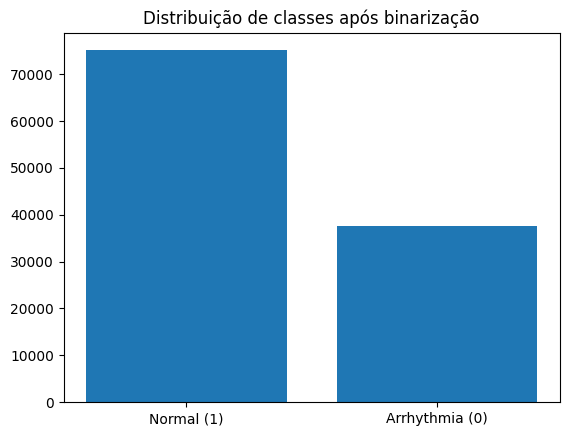

In [8]:
import matplotlib.pyplot as plt

plt.bar(['Normal (1)', 'Arrhythmia (0)'], [sum(y==1), sum(y==0)])
plt.title('Distribuição de classes após binarização')
plt.show()

In [14]:
sum(y==1), sum(y==0)

(np.int64(75052), np.int64(37595))

In [6]:
def visualize_segments(X, y, record_ids, n=5):
    """
    Visualiza n segmentos aleatórios, mostrando o tipo (normal / arritmia)
    e o número do paciente.
    """
    idx = np.random.choice(len(X), n, replace=False)
    for i in idx:
        plt.figure(figsize=(8, 2))
        plt.plot(X[i])
        plt.title(f"Patient {record_ids[i]} | Label: {'Normal (1)' if y[i]==1 else 'Arrhythmia (0)'}")
        plt.tight_layout()
        plt.show()

In [7]:
X.shape, y.shape

((112647, 360), (112647,))

[INFO] Train patients: 33 | Test patients: 15
[INFO] Train samples: 77518 | Test samples: 35129


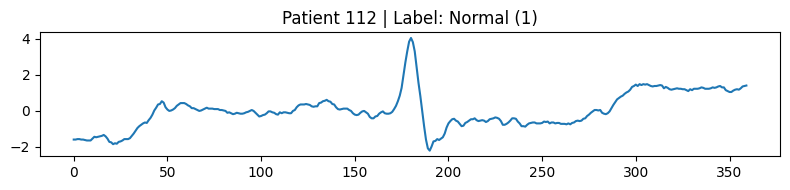

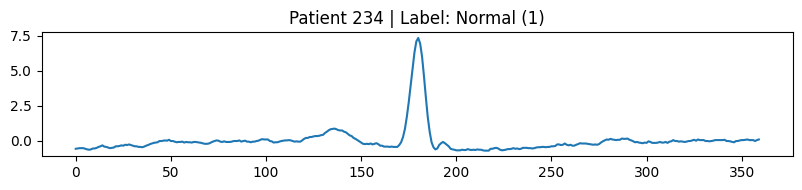

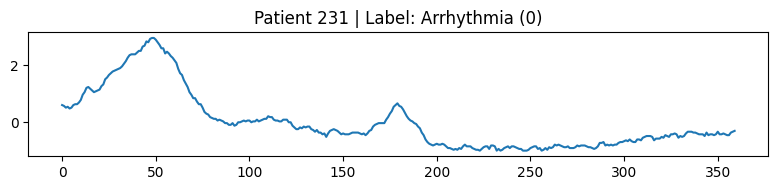

In [8]:
from src.legacy_cbms26.utils import split_by_record_id, save_preprocessed_dataset

# Separar treino/teste
X_train, X_test, y_train, y_test, rec_train, rec_test = split_by_record_id(X, y, record_ids)

# Visualizar exemplos
visualize_segments(X_train, y_train, rec_train, n=3)



In [9]:
# Salvar dataset final
save_preprocessed_dataset(X_train, X_test, y_train, y_test, rec_train, rec_test)

[INFO] Preprocessed dataset saved to data/processed/mitdb_preprocessed.npz


In [3]:
from ecg_quantification.preprocessing import ECGPreprocessor

# binário: N=1, resto=0
# pre_bin = ECGPreprocessor('data/mitbih', label_mode='binary')
# X, y, ids = pre_bin.process_all_records()

# multiclasse: apenas N/V/A/L/R, labels string
pre_multi = ECGPreprocessor('./data/raw/mitdb/', label_mode='multiclass')
X, y, ids = pre_multi.process_all_records()
# y pronto para usar com ClinicalPrevalenceBagGenerator

100: 2273 extracted segments.
101: 1863 extracted segments.
102: 103 extracted segments.
103: 2084 extracted segments.
104: 165 extracted segments.
105: 2567 extracted segments.
106: 2027 extracted segments.
107: 59 extracted segments.
108: 1760 extracted segments.
109: 2530 extracted segments.
111: 2124 extracted segments.
112: 2539 extracted segments.
113: 1789 extracted segments.
114: 1873 extracted segments.
115: 1953 extracted segments.
116: 2412 extracted segments.
117: 1535 extracted segments.
118: 2278 extracted segments.
119: 1987 extracted segments.
121: 1863 extracted segments.
122: 2476 extracted segments.
123: 1518 extracted segments.
124: 1580 extracted segments.
200: 2599 extracted segments.
201: 1853 extracted segments.
202: 2116 extracted segments.
203: 2973 extracted segments.
205: 2645 extracted segments.
207: 1755 extracted segments.
208: 2578 extracted segments.
209: 3005 extracted segments.
210: 2617 extracted segments.
212: 2748 extracted segments.
213: 2886 extr

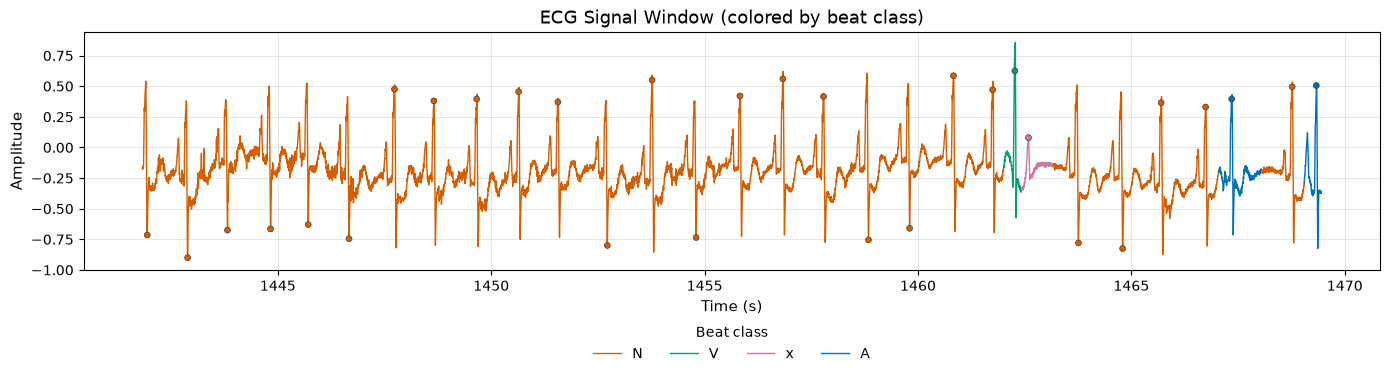

In [12]:
import wfdb
from ecg_quantification.visualization import find_variation_window, plot_signal_window

record = wfdb.rdrecord('./data/raw/mitdb/records/108')
annotation = wfdb.rdann('./data/raw/mitdb/records/108', 'atr')
signal = record.p_signal[:, 0]

start, end = find_variation_window(
    annotation.sample, np.array(annotation.symbol),
    window_beats=30, classes_of_interest=['N', 'V', 'A', 'L', 'R'],
)
fig = plot_signal_window(signal, annotation.sample, np.array(annotation.symbol), start, end,
                          sampling_rate=record.fs)
fig.savefig('signal_window.png', dpi=300)